## Importing Libraries 

In [1]:
import pandas as pd 
import numpy as np
import math as math 
import matplotlib.pyplot as plt

## Chebyshev Points  

In [2]:
def Chebyshev_Points(n, interval=(-1, 1)):
    a, b = interval

    # Generate Chebyshev points in [-1,1]
    mesh = np.zeros(n)
    for i in range(n):
        val = ((2 * i + 1) * math.pi) / (2 * n)
        mesh[i] = math.cos(val)

    # Map to [a, b]
    mesh = 0.5 * (a + b) + 0.5 * (b - a) * mesh

    # Leja ordering
    ordered_mesh = np.zeros(n)

    # Start with point of largest magnitude
    index = np.argmax(np.abs(mesh))
    ordered_mesh[0] = mesh[index]

    # remove largest point
    remaining = list(mesh)
    remaining.pop(index)

    for i in range(1, n):
        best_index = 0
        best_val = -1

        for j, candidate in enumerate(remaining):
            prod = np.prod([abs(candidate - ordered_mesh[k]) for k in range(i)])
            if prod > best_val:
                best_val = prod
                best_index = j

        ordered_mesh[i] = remaining[best_index]
        remaining.pop(best_index)

    return ordered_mesh

## Barycentric-1 Coefficients

In [3]:
def Barycentric1_Coefficients(mesh):
    n = len(mesh)
    
    # storage for weights
    gamma = np.ones(n)

    # Compute the weights
    for i in range(n):
        for j in range(n): 
            if i != j: 
                gamma[i] *= (mesh[i] - mesh[j])
                
    gamma = 1 / gamma
    
    return gamma

## Barycentric-1 Interpolation

In [4]:
def Barycentric1_Interpolation(eval_pts, mesh, gamma, fx): 
    n = len(eval_pts)

    # storage for polynomial 
    px = np.zeros(n)

    # polynomial construction
    for i in range(n): 
        x_curr = eval_pts[i]
        diff = x_curr - mesh 

        # check for spots that could be 0
        if np.any(diff == 0):
            # find the first index where diff = 0 
            j = np.where(diff == 0)[0][0]
            px[i] = fx[j]
            continue 
        
        lx = np.prod(diff)
        total = np.sum((gamma * fx) / diff)
        px[i] = lx * total
        
    return px 

## Barycentric-1 Basic Test

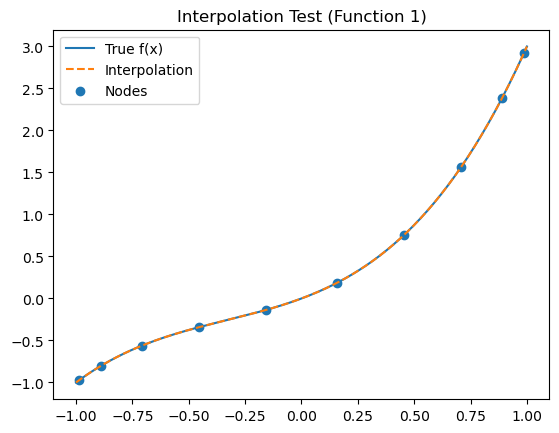

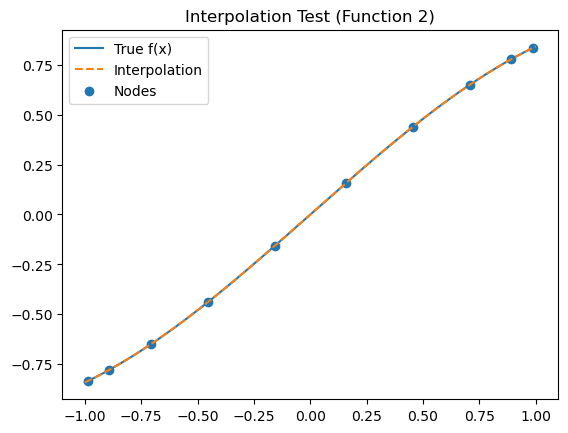

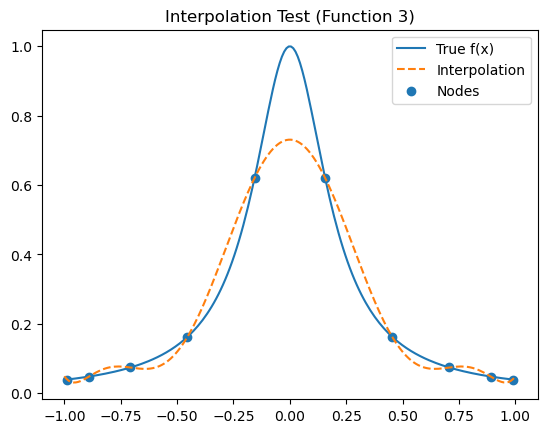

In [5]:
functions = [
    lambda x: x**3 + x**2 + x, # basic polynomial
    lambda x: np.sin(x),      # sin(x)
    lambda x: 1/(1 + 25*x**2) # Runge function
    lambda x: 
]

# True evaluation points for functions f(x) 
eval_pts = np.linspace(-1, 1, 200)

# Loop through functions
for idx, f in enumerate(functions):

    # Create mesh using chebyshev points
    mesh = Chebyshev_Points(10)
    # evaluate mesh for barycentric-1
    fx = f(mesh)
    # compute Barycentric weights
    gamma = Barycentric1_Coefficients(mesh)
    # Compute interpolating polynomial p(x) 
    px = Barycentric1_Interpolation(eval_pts, mesh, gamma, fx)
    # true f(x)
    true_vals = f(eval_pts)
    
    # Plotting True f(x) vs computed p(x)
    plt.figure()
    plt.plot(eval_pts, true_vals, label="True f(x)")
    plt.plot(eval_pts, px, '--', label="Interpolation")
    plt.scatter(mesh, fx, label="Nodes")
    plt.legend()
    plt.title(f"Interpolation Test (Function {idx+1})")
    plt.show()

## Piecewise Interpolating Polynomial